# Лабораторная работа 2  
## Адаптивная реконструкция поверхностей по облакам точек ТЛО

**Цель работы:** построить полный pipeline обработки размеченных облаков точек: загрузка данных, предобработка, формирование сегментов по `label`, геометрический анализ, классификация сегментов, автоматический выбор метода реконструкции, построение полигональных моделей и расчет метрик качества.

Данные ожидаются в папке:

```text
13/
  valve_0001_lidar_classes.ply
  valve_0002_lidar_classes.ply
  ...
  valve_0500_lidar_classes.ply
```

Каждая точка имеет формат:

```text
x y z label
```

## 0. Установка зависимостей

In [3]:
%pip install open3d trimesh scipy scikit-learn pandas matplotlib plotly tqdm


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Импорт библиотек и конфигурация

In [4]:
from pathlib import Path
import os
import math
import json
import random
import warnings
import zipfile
from dataclasses import dataclass, asdict
from typing import Dict, List, Optional, Tuple, Any

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from scipy.spatial import cKDTree, ConvexHull
from scipy.sparse.csgraph import connected_components
from sklearn.neighbors import NearestNeighbors, kneighbors_graph, radius_neighbors_graph

import open3d as o3d
O3D_AVAILABLE = True

try:
    import trimesh
    TRIMESH_AVAILABLE = True
except Exception:
    TRIMESH_AVAILABLE = False

try:
    import plotly.express as px
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
except Exception:
    PLOTLY_AVAILABLE = False

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [5]:
SEED = 52
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = Path("13")
DATA_ZIP = Path("13-20260621T195013Z-3-001.zip")

EXTRACT_DIR = Path("valve_dataset_extracted")
OUTPUT_DIR = Path("lab2_outputs")
MESH_DIR = OUTPUT_DIR / "meshes"
METRICS_DIR = OUTPUT_DIR / "metrics"
FIGURES_DIR = OUTPUT_DIR / "figures"

for d in [OUTPUT_DIR, MESH_DIR, METRICS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MAX_FILES = None

# Минимальный размер сегмента. Мелкие сегменты удаляются как шум.
MIN_SEGMENT_POINTS = 30

VOXEL_SIZE = None

MAX_POINTS_FOR_NORMALS = 1500
MAX_POINTS_FOR_CONNECTIVITY = 2500
MAX_POINTS_FOR_RECONSTRUCTION = 5000

# Параметры реконструкции.
POISSON_DEPTH = 7
ALPHA_FACTOR = 2.5
BALL_RADIUS_FACTORS = [1.5, 2.5, 4.0]

print("Open3D available:", O3D_AVAILABLE)
print("Output dir:", OUTPUT_DIR.resolve())

Open3D available: True
Output dir: /home/stavan/git/CVin3D11/sem_2/lab_2/lab2_outputs


## 2. Поиск данных `.ply`

In [6]:
def parse_ply_header(path: Path) -> Tuple[int, List[str], int]:
    """Возвращает количество вершин, список свойств и номер строки после header."""
    n_vertices = None
    properties = []
    header_end = None

    with open(path, "r", encoding="utf-8", errors="replace") as f:
        for i, line in enumerate(f):
            line = line.strip()
            if line.startswith("element vertex"):
                n_vertices = int(line.split()[-1])
            elif line.startswith("property"):
                parts = line.split()
                # property float x -> имя свойства последнее
                properties.append(parts[-1])
            elif line == "end_header":
                header_end = i + 1
                break

    if n_vertices is None or header_end is None:
        raise ValueError(f"Некорректный PLY header: {path}")

    return n_vertices, properties, header_end


def read_ascii_ply(path: Path) -> pd.DataFrame:
    """Читает ASCII .ply с полями x, y, z, label/scalar_Label."""
    path = Path(path)
    n_vertices, properties, skiprows = parse_ply_header(path)

    data = np.loadtxt(path, skiprows=skiprows, max_rows=n_vertices)
    if data.ndim == 1:
        data = data.reshape(1, -1)

    if data.shape[1] != len(properties):
        raise ValueError(
            f"Количество колонок в данных не совпадает с header: {path.name}. "
            f"data={data.shape[1]}, properties={len(properties)}"
        )

    df = pd.DataFrame(data, columns=properties)

    label_candidates = ["label", "Label", "scalar_Label", "scalar_label", "class", "Class"]
    label_col = None
    for c in label_candidates:
        if c in df.columns:
            label_col = c
            break
    if label_col is None:
        raise ValueError(f"Не найден label/scalar_Label в файле {path.name}. Колонки: {df.columns.tolist()}")

    df = df.rename(columns={label_col: "label"})
    df["label"] = df["label"].astype(int)
    df["source_file"] = path.name
    return df[["x", "y", "z", "label", "source_file"]]


def get_ply_files(data_dir: Path, max_files: Optional[int] = None) -> List[Path]:
    files = sorted(Path(data_dir).rglob("*.ply"))
    if max_files is not None:
        files = files[:max_files]
    return files

ply_files = get_ply_files(DATA_DIR, MAX_FILES)

print("DATA_DIR:", DATA_DIR)
print("Количество .ply файлов:", len(ply_files))
print("Первые 5 файлов:")
for p in ply_files[:5]:
    print(" ", p)

DATA_DIR: 13
Количество .ply файлов: 500
Первые 5 файлов:
  13/valve_0001_lidar_classes.ply
  13/valve_0002_lidar_classes.ply
  13/valve_0003_lidar_classes.ply
  13/valve_0004_lidar_classes.ply
  13/valve_0005_lidar_classes.ply


## 3. Быстрая проверка датасета

In [7]:
def dataset_summary(files: List[Path]) -> pd.DataFrame:
    rows = []
    for path in tqdm(files, desc="Проверка файлов"):
        try:
            df = read_ascii_ply(path)
            labels = np.sort(df["label"].unique())
            rows.append({
                "file": path.name,
                "n_points": len(df),
                "n_segments": len(labels),
                "min_label": int(labels.min()) if len(labels) else None,
                "max_label": int(labels.max()) if len(labels) else None,
                "labels": ",".join(map(str, labels.tolist())),
                "has_nan": bool(df[["x", "y", "z"]].isna().any().any()),
            })
        except Exception as exc:
            rows.append({
                "file": path.name,
                "error": repr(exc),
            })
    return pd.DataFrame(rows)

summary_df = dataset_summary(ply_files)
summary_path = METRICS_DIR / "dataset_summary.csv"
summary_df.to_csv(summary_path, index=False)

summary_df.head()

Проверка файлов:   0%|          | 0/500 [00:00<?, ?it/s]

,file,n_points,n_segments,min_label,max_label,labels,has_nan
0,valve_0001_lidar_classes.ply,7218,10,0,9,"0,1,2,3,4,5,6,7,8,9",False
1,valve_0002_lidar_classes.ply,7106,10,0,9,"0,1,2,3,4,5,6,7,8,9",False
2,valve_0003_lidar_classes.ply,7368,10,0,9,"0,1,2,3,4,5,6,7,8,9",False
3,valve_0004_lidar_classes.ply,7220,10,0,9,"0,1,2,3,4,5,6,7,8,9",False
4,valve_0005_lidar_classes.ply,8268,10,0,9,"0,1,2,3,4,5,6,7,8,9",False


Размер summary: (500, 7)
Файлов с ошибками: 0
Статистика по числу точек:


count     500.000000
mean     7787.488000
std       567.485755
min      6715.000000
25%      7367.500000
50%      7741.000000
75%      8268.750000
max      9058.000000
Name: n_points, dtype: float64

Статистика по числу сегментов:


count    500.0
mean      10.0
std        0.0
min       10.0
25%       10.0
50%       10.0
75%       10.0
max       10.0
Name: n_segments, dtype: float64

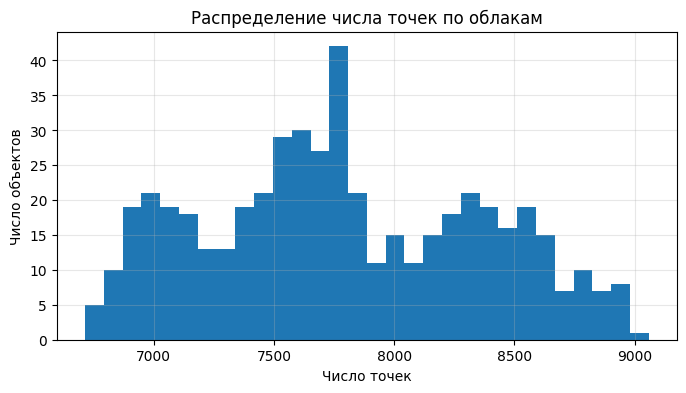

In [8]:
print("Размер summary:", summary_df.shape)
print("Файлов с ошибками:", summary_df.get("error", pd.Series(dtype=object)).notna().sum() if "error" in summary_df else 0)

valid_summary = summary_df[summary_df.get("error", pd.Series([None] * len(summary_df))).isna()] if "error" in summary_df else summary_df
print("Статистика по числу точек:")
display(valid_summary["n_points"].describe())
print("Статистика по числу сегментов:")
display(valid_summary["n_segments"].describe())

plt.figure(figsize=(8, 4))
plt.hist(valid_summary["n_points"], bins=30)
plt.title("Распределение числа точек по облакам")
plt.xlabel("Число точек")
plt.ylabel("Число объектов")
plt.grid(True, alpha=0.3)
plt.show()

Распределение label:   0%|          | 0/500 [00:00<?, ?it/s]

,label,n_points
0,0,643778
1,1,454864
2,2,233413
3,3,311555
4,4,32343
5,5,46691
6,6,352314
7,7,340708
8,8,23057
9,9,1455021


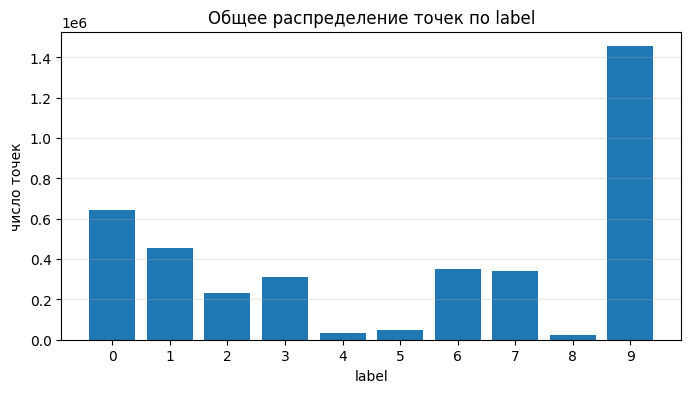

In [9]:
def collect_label_distribution(files: List[Path]) -> pd.DataFrame:
    rows = []
    for path in tqdm(files, desc="Распределение label"):
        df = read_ascii_ply(path)
        counts = df["label"].value_counts().sort_index()
        for label, cnt in counts.items():
            rows.append({"file": path.name, "label": int(label), "n_points": int(cnt)})
    return pd.DataFrame(rows)

label_dist_df = collect_label_distribution(ply_files)
label_dist_path = METRICS_DIR / "label_distribution.csv"
label_dist_df.to_csv(label_dist_path, index=False)

label_global = label_dist_df.groupby("label")["n_points"].sum().reset_index()
display(label_global)

plt.figure(figsize=(8, 4))
plt.bar(label_global["label"].astype(str), label_global["n_points"])
plt.title("Общее распределение точек по label")
plt.xlabel("label")
plt.ylabel("число точек")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## 4. Визуализация исходного облака точек

In [10]:
def sample_points_for_plot(df: pd.DataFrame, max_points: int = 6000) -> pd.DataFrame:
    if len(df) <= max_points:
        return df.copy()
    return df.sample(max_points, random_state=SEED)


def plot_cloud_3d(df: pd.DataFrame, title: str = "Облако точек", max_points: int = 6000):
    sample_df = sample_points_for_plot(df, max_points=max_points)
    if PLOTLY_AVAILABLE:
        fig = px.scatter_3d(
            sample_df,
            x="x", y="y", z="z",
            color=sample_df["label"].astype(str),
            opacity=0.75,
            title=title,
            height=700,
        )
        fig.update_traces(marker=dict(size=2))
        fig.show()
    else:
        fig = plt.figure(figsize=(8, 7))
        ax = fig.add_subplot(111, projection="3d")
        sc = ax.scatter(sample_df["x"], sample_df["y"], sample_df["z"], c=sample_df["label"], s=2, cmap="tab10")
        ax.set_title(title)
        plt.colorbar(sc, ax=ax, label="label")
        plt.show()

example_df = read_ascii_ply(ply_files[0])
print(example_df.head())
plot_cloud_3d(example_df, title=f"Пример: {ply_files[0].name}")

            x          y          z  label                   source_file
0  112.797378  57.071579   2.998605      0  valve_0001_lidar_classes.ply
1  118.447946  54.140083  17.194816      0  valve_0001_lidar_classes.ply
2  121.218277  50.871410  24.005737      0  valve_0001_lidar_classes.ply
3  123.298255  47.566218  29.024820      0  valve_0001_lidar_classes.ply
4  125.035943  44.262601  33.141063      0  valve_0001_lidar_classes.ply


## 5. Предобработка: проверка, удаление шума, нормализация, downsampling

До: 7218 После: 7072
Transform: {'center': [-30.715227708993215, 27.44322355147059, 13.5715338280543], 'scale': 323.9744495493939}


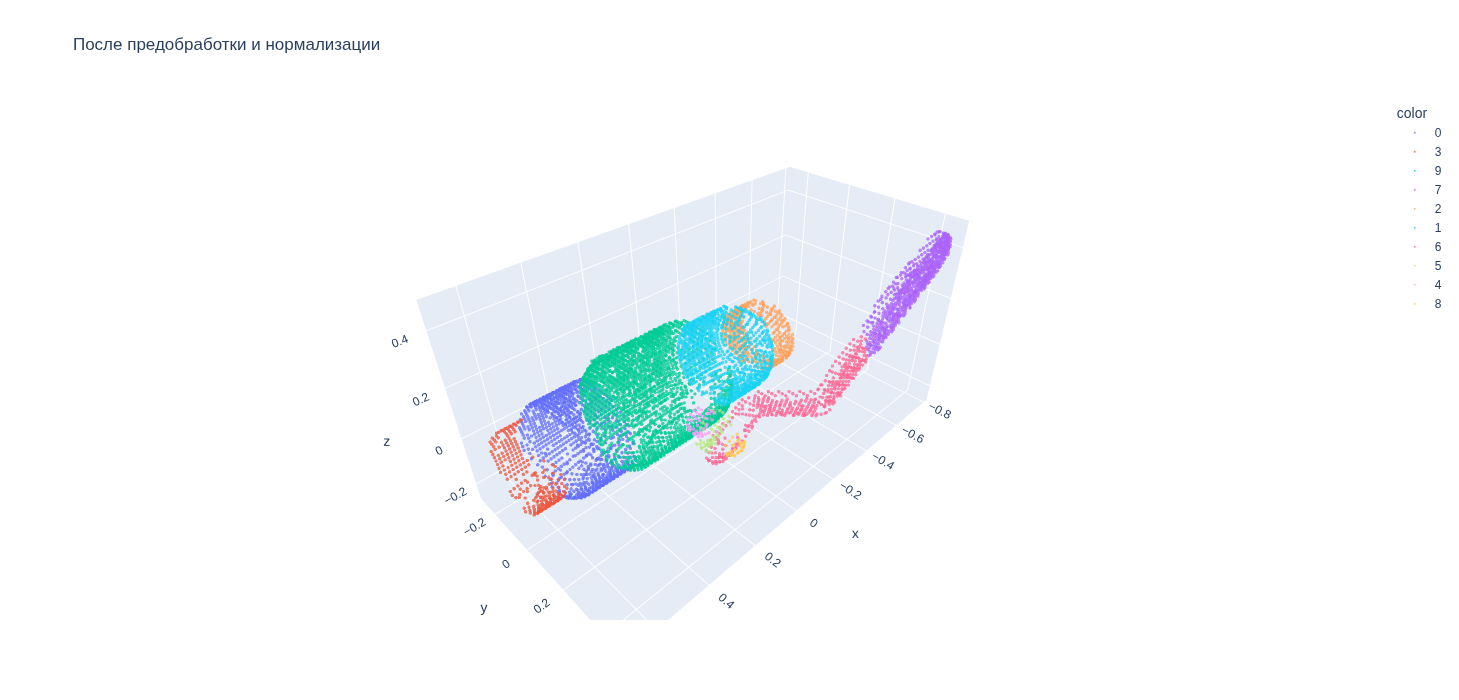

In [11]:
def remove_invalid_points(df: pd.DataFrame) -> pd.DataFrame:
    before = len(df)
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=["x", "y", "z", "label"])
    df = df.drop_duplicates(subset=["x", "y", "z", "label"])
    after = len(df)
    if after < before:
        print(f"Удалено некорректных/дублирующихся точек: {before - after}")
    return df.reset_index(drop=True)


def statistical_outlier_filter(points: np.ndarray, k: int = 16, z_threshold: float = 2.5) -> np.ndarray:
    """Возвращает boolean mask точек, не являющихся статистическими выбросами."""
    if len(points) <= k + 1:
        return np.ones(len(points), dtype=bool)
    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(points)
    dists, _ = nbrs.kneighbors(points)
    mean_dists = dists[:, 1:].mean(axis=1)
    mu = mean_dists.mean()
    sigma = mean_dists.std() + 1e-12
    z = (mean_dists - mu) / sigma
    return z < z_threshold


def normalize_points(points: np.ndarray) -> Tuple[np.ndarray, Dict[str, Any]]:
    """Центрирование и масштабирование в единичную сферу."""
    center = points.mean(axis=0)
    centered = points - center
    scale = np.linalg.norm(centered, axis=1).max()
    if scale < 1e-12:
        scale = 1.0
    normalized = centered / scale
    transform = {"center": center.tolist(), "scale": float(scale)}
    return normalized, transform


def voxel_downsample_majority_label(df: pd.DataFrame, voxel_size: Optional[float]) -> pd.DataFrame:
    """Voxel downsampling с выбором большинства label внутри вокселя."""
    if voxel_size is None or voxel_size <= 0:
        return df
    pts = df[["x", "y", "z"]].to_numpy()
    labels = df["label"].to_numpy()
    vox = np.floor(pts / voxel_size).astype(np.int64)
    tmp = pd.DataFrame({
        "vx": vox[:, 0], "vy": vox[:, 1], "vz": vox[:, 2],
        "x": pts[:, 0], "y": pts[:, 1], "z": pts[:, 2],
        "label": labels,
    })
    grouped = []
    for _, g in tmp.groupby(["vx", "vy", "vz"], sort=False):
        label = int(g["label"].mode().iloc[0])
        grouped.append({
            "x": g["x"].mean(),
            "y": g["y"].mean(),
            "z": g["z"].mean(),
            "label": label,
        })
    return pd.DataFrame(grouped)


def preprocess_cloud(
    df: pd.DataFrame,
    remove_outliers: bool = True,
    normalize: bool = True,
    voxel_size: Optional[float] = VOXEL_SIZE,
) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """Полная предобработка одного облака."""
    df = remove_invalid_points(df)

    if remove_outliers:
        mask_all = np.zeros(len(df), dtype=bool)
        # Удаление выбросов внутри каждого label, чтобы не стереть маленькие детали.
        for label, idx in df.groupby("label").groups.items():
            idx = np.array(list(idx))
            pts = df.loc[idx, ["x", "y", "z"]].to_numpy()
            mask = statistical_outlier_filter(pts, k=16, z_threshold=2.8)
            mask_all[idx[mask]] = True
        df = df.loc[mask_all].reset_index(drop=True)

    df = voxel_downsample_majority_label(df, voxel_size=voxel_size)

    transform = {"center": [0, 0, 0], "scale": 1.0}
    if normalize:
        pts = df[["x", "y", "z"]].to_numpy(dtype=float)
        pts_norm, transform = normalize_points(pts)
        df = df.copy()
        df[["x", "y", "z"]] = pts_norm

    return df.reset_index(drop=True), transform

pre_df, transform = preprocess_cloud(example_df)
print("До:", len(example_df), "После:", len(pre_df))
print("Transform:", transform)
plot_cloud_3d(pre_df, title="После предобработки и нормализации")

## 6. Формирование сегментов по `label`

In [12]:
def split_into_segments(df: pd.DataFrame, min_points: int = MIN_SEGMENT_POINTS) -> List[Dict[str, Any]]:
    segments = []
    for label, g in df.groupby("label"):
        pts = g[["x", "y", "z"]].to_numpy(dtype=float)
        if len(pts) < min_points:
            continue
        segments.append({
            "label": int(label),
            "points": pts,
            "n_points": int(len(pts)),
        })
    return segments

segments = split_into_segments(pre_df)
print("Количество сегментов:", len(segments))
print(pd.DataFrame([{"label": s["label"], "n_points": s["n_points"]} for s in segments]))

Количество сегментов: 10
   label  n_points
0      0      1169
1      1      1078
2      2       478
3      3       284
4      4        44
5      5        64
6      6       486
7      7       788
8      8        39
9      9      2642


## 7. Геометрический анализ сегментов

In [13]:
def pca_features(points: np.ndarray) -> Dict[str, float]:
    """PCA-признаки формы распределения точек."""
    if len(points) < 3:
        return {k: np.nan for k in [
            "lambda1", "lambda2", "lambda3", "linearity", "planarity", "scattering",
            "anisotropy", "curvature", "eigen_entropy"
        ]}

    centered = points - points.mean(axis=0)
    cov = np.cov(centered.T)
    eigvals = np.linalg.eigvalsh(cov)
    eigvals = np.sort(np.maximum(eigvals, 1e-12))[::-1]
    l1, l2, l3 = eigvals
    s = eigvals.sum() + 1e-12
    p = eigvals / s

    return {
        "lambda1": float(l1),
        "lambda2": float(l2),
        "lambda3": float(l3),
        "linearity": float((l1 - l2) / (l1 + 1e-12)),
        "planarity": float((l2 - l3) / (l1 + 1e-12)),
        "scattering": float(l3 / (l1 + 1e-12)),
        "anisotropy": float((l1 - l3) / (l1 + 1e-12)),
        "curvature": float(l3 / s),
        "eigen_entropy": float(-(p * np.log(p + 1e-12)).sum()),
    }


def bbox_features(points: np.ndarray) -> Dict[str, float]:
    mins = points.min(axis=0)
    maxs = points.max(axis=0)
    extents = np.maximum(maxs - mins, 1e-12)
    bbox_volume = float(np.prod(extents))
    diag = float(np.linalg.norm(extents))
    sorted_ext = np.sort(extents)[::-1]
    return {
        "bbox_x": float(extents[0]),
        "bbox_y": float(extents[1]),
        "bbox_z": float(extents[2]),
        "bbox_diag": diag,
        "bbox_volume": bbox_volume,
        "extent_1": float(sorted_ext[0]),
        "extent_2": float(sorted_ext[1]),
        "extent_3": float(sorted_ext[2]),
        "extent_ratio_12": float(sorted_ext[1] / (sorted_ext[0] + 1e-12)),
        "extent_ratio_23": float(sorted_ext[2] / (sorted_ext[1] + 1e-12)),
    }


def density_features(points: np.ndarray) -> Dict[str, float]:
    b = bbox_features(points)
    volume = b["bbox_volume"]
    density = len(points) / (volume + 1e-12)
    return {"density_bbox": float(density)}


def estimate_normals_pca(points: np.ndarray, k: int = 24, max_points: int = MAX_POINTS_FOR_NORMALS) -> np.ndarray:
    """Оценка нормалей через локальную PCA. Для скорости используется подвыборка."""
    if len(points) < k + 1:
        return np.empty((0, 3))

    if len(points) > max_points:
        idx = np.random.choice(len(points), size=max_points, replace=False)
        pts = points[idx]
    else:
        pts = points

    nbrs = NearestNeighbors(n_neighbors=min(k + 1, len(pts))).fit(pts)
    _, inds = nbrs.kneighbors(pts)

    normals = []
    for neigh_idx in inds:
        neigh = pts[neigh_idx[1:]]
        cov = np.cov((neigh - neigh.mean(axis=0)).T)
        eigvals, eigvecs = np.linalg.eigh(cov)
        n = eigvecs[:, np.argmin(eigvals)]
        n = n / (np.linalg.norm(n) + 1e-12)
        normals.append(n)
    return np.asarray(normals)


def normal_consistency_features(points: np.ndarray) -> Dict[str, float]:
    normals = estimate_normals_pca(points)
    if len(normals) < 2:
        return {"normal_consistency": np.nan}

    # Согласованность оценивается как среднее |cos| между нормалями соседних точек.
    nbrs = NearestNeighbors(n_neighbors=min(8, len(normals))).fit(normals)
    _, inds = nbrs.kneighbors(normals)
    vals = []
    for i, neigh in enumerate(inds):
        dots = np.abs(normals[i] @ normals[neigh[1:]].T)
        vals.extend(dots.tolist())
    return {"normal_consistency": float(np.mean(vals)) if vals else np.nan}


def connectivity_features(points: np.ndarray, max_points: int = MAX_POINTS_FOR_CONNECTIVITY) -> Dict[str, float]:
    """Топологическая связность через kNN-граф."""
    if len(points) < 3:
        return {"n_components": 1, "largest_component_ratio": 1.0}

    if len(points) > max_points:
        idx = np.random.choice(len(points), size=max_points, replace=False)
        pts = points[idx]
    else:
        pts = points

    k = min(10, len(pts) - 1)
    graph = kneighbors_graph(pts, n_neighbors=k, mode="connectivity", include_self=False)
    n_comp, labels = connected_components(graph, directed=False)
    counts = np.bincount(labels)
    largest_ratio = counts.max() / counts.sum()
    return {
        "n_components": int(n_comp),
        "largest_component_ratio": float(largest_ratio),
    }


def analyze_segment(points: np.ndarray) -> Dict[str, Any]:
    feats = {}
    feats.update({"n_points": int(len(points))})
    feats.update(pca_features(points))
    feats.update(bbox_features(points))
    feats.update(density_features(points))
    feats.update(normal_consistency_features(points))
    feats.update(connectivity_features(points))
    return feats

segment_features = []
for s in tqdm(segments, desc="Анализ сегментов примера"):
    feats = analyze_segment(s["points"])
    feats["label"] = s["label"]
    segment_features.append(feats)

features_df = pd.DataFrame(segment_features)
display(features_df)

Анализ сегментов примера:   0%|          | 0/10 [00:00<?, ?it/s]

,n_points,lambda1,lambda2,lambda3,linearity,planarity,scattering,anisotropy,curvature,eigen_entropy,...,extent_1,extent_2,extent_3,extent_ratio_12,extent_ratio_23,density_bbox,normal_consistency,n_components,largest_component_ratio,label
0,1169,0.015810,0.012827,0.003579,0.188713,0.584907,0.226380,0.773620,0.111098,0.960111,...,0.353063,0.332967,0.228434,0.943083,0.686055,43531.223240,0.997351,1,1.0,0
1,1078,0.014906,0.010528,0.004309,0.293719,0.417243,0.289038,0.710962,0.144858,0.993691,...,0.333028,0.309496,0.236740,0.929342,0.764919,44178.580070,0.996084,1,1.0,1
2,478,0.012042,0.006335,0.001021,0.473969,0.441268,0.084763,0.915237,0.052622,0.816377,...,0.284686,0.274148,0.114278,0.962984,0.416849,53593.685861,0.997216,1,1.0,2
3,284,0.010604,0.005110,0.000829,0.518116,0.403681,0.078203,0.921797,0.050127,0.797989,...,0.259931,0.252531,0.107906,0.971529,0.427299,40095.780950,0.995899,1,1.0,3
4,44,0.001601,0.000874,0.000233,0.454004,0.400423,0.145573,0.854427,0.086058,0.886822,...,0.101201,0.095623,0.058410,0.944877,0.610839,77842.824127,0.925674,1,1.0,4
5,64,0.001883,0.000878,0.000318,0.533665,0.297544,0.168791,0.831209,0.103228,0.892936,...,0.134535,0.120500,0.057977,0.895674,0.481138,68092.864609,0.913288,1,1.0,5
6,486,0.029927,0.001884,0.001059,0.937054,0.027572,0.035375,0.964625,0.032208,0.359907,...,0.534396,0.368208,0.212854,0.689018,0.578080,11603.735152,0.996685,1,1.0,6
7,788,0.018438,0.001736,0.000180,0.905830,0.084397,0.009774,0.990226,0.008853,0.341406,...,0.457896,0.325823,0.043700,0.711566,0.134122,120863.306247,0.993493,1,1.0,7
8,39,0.000533,0.000443,0.000078,0.167821,0.685434,0.146746,0.853254,0.074154,0.902112,...,0.077036,0.071543,0.032550,0.928690,0.454970,217396.698973,0.962740,1,1.0,8
9,2642,0.019186,0.018477,0.014611,0.036918,0.201527,0.761555,0.238445,0.279507,1.091767,...,0.464055,0.410417,0.377776,0.884414,0.920468,36720.146396,0.996963,1,1.0,9


## 8. Классификация сегментов по геометрии

In [14]:
def classify_geometry(feats: Dict[str, Any]) -> str:
    """Правила классификации сегмента: plane / tubular / spherical / complex."""
    linearity = feats.get("linearity", 0.0)
    planarity = feats.get("planarity", 0.0)
    scattering = feats.get("scattering", 0.0)
    curvature = feats.get("curvature", 0.0)
    normal_consistency = feats.get("normal_consistency", 0.0)
    extent_ratio_12 = feats.get("extent_ratio_12", 0.0)
    extent_ratio_23 = feats.get("extent_ratio_23", 0.0)

    # Плоскость: высокая планарность, малая кривизна, согласованные нормали.
    if planarity > 0.45 and curvature < 0.06 and normal_consistency > 0.70:
        return "plane"

    # Трубчатая форма: выраженная главная ось, две вторичные оси относительно близки.
    if linearity > 0.45 and extent_ratio_12 < 0.65 and extent_ratio_23 > 0.35:
        return "tubular"

    # Сферическая форма: распределение более равномерное по трем осям.
    if extent_ratio_12 > 0.65 and extent_ratio_23 > 0.65 and scattering > 0.20:
        return "spherical"

    return "complex"


def select_reconstruction_method(geometry_type: str, feats: Dict[str, Any]) -> str:
    """Автоматический выбор метода реконструкции."""
    n_points = feats.get("n_points", 0)
    normal_consistency = feats.get("normal_consistency", 0.0)

    if n_points < 100:
        return "alpha_shape"

    if geometry_type == "plane":
        return "alpha_shape"

    if geometry_type == "tubular":
        return "ball_pivoting"

    if geometry_type == "spherical":
        return "poisson"

    if normal_consistency > 0.65:
        return "poisson"
    return "alpha_shape"

features_df["geometry_type"] = features_df.apply(lambda r: classify_geometry(r.to_dict()), axis=1)
features_df["reconstruction_method"] = features_df.apply(lambda r: select_reconstruction_method(r["geometry_type"], r.to_dict()), axis=1)
display(features_df[["label", "n_points", "linearity", "planarity", "scattering", "curvature", "normal_consistency", "geometry_type", "reconstruction_method"]])

,label,n_points,linearity,planarity,scattering,curvature,normal_consistency,geometry_type,reconstruction_method
0,0,1169,0.188713,0.584907,0.226380,0.111098,0.997351,spherical,poisson
1,1,1078,0.293719,0.417243,0.289038,0.144858,0.996084,spherical,poisson
2,2,478,0.473969,0.441268,0.084763,0.052622,0.997216,complex,poisson
3,3,284,0.518116,0.403681,0.078203,0.050127,0.995899,complex,poisson
4,4,44,0.454004,0.400423,0.145573,0.086058,0.925674,complex,alpha_shape
5,5,64,0.533665,0.297544,0.168791,0.103228,0.913288,complex,alpha_shape
6,6,486,0.937054,0.027572,0.035375,0.032208,0.996685,complex,poisson
7,7,788,0.905830,0.084397,0.009774,0.008853,0.993493,complex,poisson
8,8,39,0.167821,0.685434,0.146746,0.074154,0.962740,complex,alpha_shape
9,9,2642,0.036918,0.201527,0.761555,0.279507,0.996963,spherical,poisson


## 9. Реконструкция поверхности сегмента

In [15]:
def limit_points(points: np.ndarray, max_points: Optional[int] = MAX_POINTS_FOR_RECONSTRUCTION) -> np.ndarray:
    if max_points is None or len(points) <= max_points:
        return points
    idx = np.random.choice(len(points), size=max_points, replace=False)
    return points[idx]


def mean_nearest_neighbor_distance(points: np.ndarray, k: int = 2) -> float:
    if len(points) < 2:
        return 0.01
    nbrs = NearestNeighbors(n_neighbors=min(k, len(points))).fit(points)
    dists, _ = nbrs.kneighbors(points)
    if dists.shape[1] <= 1:
        return float(np.mean(dists))
    return float(np.mean(dists[:, 1]))


def make_o3d_point_cloud(points: np.ndarray, estimate_normals: bool = True) -> "o3d.geometry.PointCloud":
    if not O3D_AVAILABLE:
        raise ImportError("Open3D не установлен. Выполните: %pip install open3d")
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points.astype(np.float64))
    if estimate_normals and len(points) >= 4:
        nn = mean_nearest_neighbor_distance(points)
        radius = max(nn * 4.0, 1e-3)
        pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=radius, max_nn=30))
        pcd.orient_normals_consistent_tangent_plane(k=min(30, max(3, len(points) - 1)))
    return pcd


def clean_mesh(mesh: "o3d.geometry.TriangleMesh") -> "o3d.geometry.TriangleMesh":
    mesh.remove_duplicated_vertices()
    mesh.remove_duplicated_triangles()
    mesh.remove_degenerate_triangles()
    mesh.remove_non_manifold_edges()
    mesh.compute_vertex_normals()
    return mesh


def reconstruct_poisson(points: np.ndarray, depth: int = POISSON_DEPTH) -> "o3d.geometry.TriangleMesh":
    pcd = make_o3d_point_cloud(points, estimate_normals=True)
    mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
        pcd, depth=depth, width=0, scale=1.1, linear_fit=False
    )
    # Обрезаем сетку по bounding box исходного сегмента.
    bbox = pcd.get_axis_aligned_bounding_box()
    bbox = bbox.scale(1.05, bbox.get_center())
    mesh = mesh.crop(bbox)
    return clean_mesh(mesh)


def reconstruct_alpha_shape(points: np.ndarray, alpha_factor: float = ALPHA_FACTOR) -> "o3d.geometry.TriangleMesh":
    pcd = make_o3d_point_cloud(points, estimate_normals=False)
    nn = mean_nearest_neighbor_distance(points)
    alpha = max(nn * alpha_factor, 1e-4)
    mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_alpha_shape(pcd, alpha)
    return clean_mesh(mesh)


def reconstruct_ball_pivoting(points: np.ndarray, radius_factors: List[float] = BALL_RADIUS_FACTORS) -> "o3d.geometry.TriangleMesh":
    pcd = make_o3d_point_cloud(points, estimate_normals=True)
    nn = mean_nearest_neighbor_distance(points)
    radii = [max(nn * f, 1e-4) for f in radius_factors]
    mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(
        pcd, o3d.utility.DoubleVector(radii)
    )
    return clean_mesh(mesh)


def reconstruct_segment(points: np.ndarray, method: str) -> "o3d.geometry.TriangleMesh":
    pts = limit_points(points)
    if len(pts) < 4:
        raise ValueError("Недостаточно точек для реконструкции")

    if method == "poisson":
        return reconstruct_poisson(pts)
    if method == "alpha_shape":
        return reconstruct_alpha_shape(pts)
    if method == "ball_pivoting":
        return reconstruct_ball_pivoting(pts)
    raise ValueError(f"Неизвестный метод реконструкции: {method}")


def reconstruct_segment_with_fallback(points: np.ndarray, method: str) -> Tuple["o3d.geometry.TriangleMesh", str]:
    """Реконструкция с fallback: если выбранный метод падает, пробуются альтернативы."""
    fallback_order = [method, "ball_pivoting", "poisson", "alpha_shape"]
    fallback_order = list(dict.fromkeys(fallback_order))
    errors = []

    for m in fallback_order:
        try:
            mesh = reconstruct_segment(points, m)
            if len(mesh.vertices) > 0 and len(mesh.triangles) > 0:
                return mesh, m
            errors.append(f"{m}: empty mesh")
        except Exception as exc:
            errors.append(f"{m}: {repr(exc)}")

    raise RuntimeError("Все методы реконструкции завершились ошибкой: " + " | ".join(errors))

## 10. Метрики качества реконструкции

In [16]:
def mesh_to_arrays(mesh: "o3d.geometry.TriangleMesh") -> Tuple[np.ndarray, np.ndarray]:
    vertices = np.asarray(mesh.vertices)
    triangles = np.asarray(mesh.triangles)
    return vertices, triangles


def triangle_aspect_ratios(vertices: np.ndarray, triangles: np.ndarray) -> np.ndarray:
    if len(triangles) == 0:
        return np.array([])
    tri = vertices[triangles]
    a = np.linalg.norm(tri[:, 0] - tri[:, 1], axis=1)
    b = np.linalg.norm(tri[:, 1] - tri[:, 2], axis=1)
    c = np.linalg.norm(tri[:, 2] - tri[:, 0], axis=1)
    min_edge = np.maximum(np.minimum(np.minimum(a, b), c), 1e-12)
    max_edge = np.maximum(np.maximum(a, b), c)
    return max_edge / min_edge


def approximate_chamfer_metrics(points: np.ndarray, mesh: "o3d.geometry.TriangleMesh", sample_n: int = 10000) -> Dict[str, float]:
    """Приближенная оценка отклонения: point cloud <-> sampled mesh cloud."""
    if len(mesh.vertices) == 0 or len(mesh.triangles) == 0:
        return {
            "pc_to_mesh_mean": np.nan,
            "pc_to_mesh_rmse": np.nan,
            "pc_to_mesh_p95": np.nan,
            "mesh_to_pc_mean": np.nan,
            "chamfer_mean": np.nan,
        }

    n_sample = min(sample_n, max(1000, len(points)))
    mesh_pcd = mesh.sample_points_uniformly(number_of_points=n_sample)
    mesh_pts = np.asarray(mesh_pcd.points)

    tree_mesh = cKDTree(mesh_pts)
    d_pc_to_mesh, _ = tree_mesh.query(points, k=1)

    tree_pc = cKDTree(points)
    d_mesh_to_pc, _ = tree_pc.query(mesh_pts, k=1)

    return {
        "pc_to_mesh_mean": float(np.mean(d_pc_to_mesh)),
        "pc_to_mesh_rmse": float(np.sqrt(np.mean(d_pc_to_mesh ** 2))),
        "pc_to_mesh_p95": float(np.percentile(d_pc_to_mesh, 95)),
        "mesh_to_pc_mean": float(np.mean(d_mesh_to_pc)),
        "chamfer_mean": float(np.mean(d_pc_to_mesh) + np.mean(d_mesh_to_pc)),
    }


def mesh_connectivity_metrics(mesh: "o3d.geometry.TriangleMesh") -> Dict[str, float]:
    if len(mesh.triangles) == 0:
        return {"mesh_components": 0, "largest_mesh_component_ratio": 0.0}
    triangle_clusters, cluster_n_triangles, _ = mesh.cluster_connected_triangles()
    cluster_n_triangles = np.asarray(cluster_n_triangles)
    if len(cluster_n_triangles) == 0:
        return {"mesh_components": 0, "largest_mesh_component_ratio": 0.0}
    return {
        "mesh_components": int(len(cluster_n_triangles)),
        "largest_mesh_component_ratio": float(cluster_n_triangles.max() / cluster_n_triangles.sum()),
    }


def mesh_smoothness_metrics(mesh: "o3d.geometry.TriangleMesh") -> Dict[str, float]:
    vertices, triangles = mesh_to_arrays(mesh)
    if len(triangles) == 0:
        return {"mean_adjacent_face_angle": np.nan, "smoothness_score": np.nan}
    if not TRIMESH_AVAILABLE:
        return {"mean_adjacent_face_angle": np.nan, "smoothness_score": np.nan}
    tm = trimesh.Trimesh(vertices=vertices, faces=triangles, process=False)
    angles = getattr(tm, "face_adjacency_angles", np.array([]))
    if len(angles) == 0:
        return {"mean_adjacent_face_angle": np.nan, "smoothness_score": np.nan}
    mean_angle = float(np.mean(np.abs(angles)))
    return {
        "mean_adjacent_face_angle": mean_angle,
        "smoothness_score": float(1.0 / (1.0 + mean_angle)),
    }


def mesh_artifact_metrics(mesh: "o3d.geometry.TriangleMesh") -> Dict[str, float]:
    vertices, triangles = mesh_to_arrays(mesh)
    ratios = triangle_aspect_ratios(vertices, triangles)
    if len(ratios) == 0:
        return {
            "n_vertices": int(len(vertices)),
            "n_triangles": int(len(triangles)),
            "bad_triangle_ratio": np.nan,
            "mean_aspect_ratio": np.nan,
            "artifact_score": np.nan,
        }
    bad_ratio = float(np.mean(ratios > 10.0))
    return {
        "n_vertices": int(len(vertices)),
        "n_triangles": int(len(triangles)),
        "bad_triangle_ratio": bad_ratio,
        "mean_aspect_ratio": float(np.mean(ratios)),
        "artifact_score": float(1.0 - bad_ratio),
    }


def evaluate_reconstruction(points: np.ndarray, mesh: "o3d.geometry.TriangleMesh") -> Dict[str, float]:
    metrics = {}
    metrics.update(approximate_chamfer_metrics(points, mesh))
    metrics.update(mesh_connectivity_metrics(mesh))
    metrics.update(mesh_smoothness_metrics(mesh))
    metrics.update(mesh_artifact_metrics(mesh))

    bbox_diag = np.linalg.norm(points.max(axis=0) - points.min(axis=0)) + 1e-12
    rmse_norm = metrics["pc_to_mesh_rmse"] / bbox_diag if not np.isnan(metrics["pc_to_mesh_rmse"]) else np.nan
    metrics["rmse_normalized"] = float(rmse_norm) if not np.isnan(rmse_norm) else np.nan
    metrics["accuracy_score"] = float(1.0 / (1.0 + rmse_norm)) if not np.isnan(rmse_norm) else np.nan
    metrics["connectivity_score"] = float(1.0 / max(metrics.get("mesh_components", 1), 1))

    quality_parts = [
        metrics.get("accuracy_score", np.nan),
        metrics.get("smoothness_score", np.nan),
        metrics.get("connectivity_score", np.nan),
        metrics.get("artifact_score", np.nan),
    ]
    quality_parts = [x for x in quality_parts if not pd.isna(x)]
    metrics["global_quality_score"] = float(np.mean(quality_parts)) if quality_parts else np.nan
    return metrics

## 11. Полный пайплайн обработки одного файла

In [17]:
def color_by_label(label: int) -> Tuple[float, float, float]:
    palette = np.array([
        [0.121, 0.466, 0.705],
        [1.000, 0.498, 0.054],
        [0.172, 0.627, 0.172],
        [0.839, 0.153, 0.157],
        [0.580, 0.404, 0.741],
        [0.549, 0.337, 0.294],
        [0.890, 0.467, 0.761],
        [0.498, 0.498, 0.498],
        [0.737, 0.741, 0.133],
        [0.090, 0.745, 0.811],
    ])
    return tuple(palette[label % len(palette)].tolist())


def process_one_file(path: Path, export_mesh: bool = True) -> Tuple[pd.DataFrame, Optional["o3d.geometry.TriangleMesh"]]:
    """Обрабатывает один .ply: предобработка -> сегменты -> анализ -> метод -> реконструкция -> метрики."""
    raw_df = read_ascii_ply(path)
    pre_df, transform = preprocess_cloud(raw_df, remove_outliers=True, normalize=True, voxel_size=VOXEL_SIZE)
    segments = split_into_segments(pre_df, min_points=MIN_SEGMENT_POINTS)

    rows = []
    full_mesh = None

    if O3D_AVAILABLE:
        full_mesh = o3d.geometry.TriangleMesh()

    for segment in segments:
        label = segment["label"]
        points = segment["points"]
        row = {
            "file": path.name,
            "label": label,
            "segment_points": len(points),
            "status": "ok",
            "error": None,
        }

        try:
            feats = analyze_segment(points)
            geometry_type = classify_geometry(feats)
            method = select_reconstruction_method(geometry_type, feats)

            row.update(feats)
            row["geometry_type"] = geometry_type
            row["reconstruction_method"] = method

            if O3D_AVAILABLE:
                mesh, used_method = reconstruct_segment_with_fallback(points, method)
                row["used_reconstruction_method"] = used_method
                row["used_fallback"] = bool(used_method != method)
                mesh.paint_uniform_color(color_by_label(label))
                metrics = evaluate_reconstruction(points, mesh)
                row.update(metrics)

                if export_mesh:
                    segment_dir = MESH_DIR / path.stem
                    segment_dir.mkdir(parents=True, exist_ok=True)
                    mesh_path = segment_dir / f"segment_{label:02d}_{geometry_type}_{method}.ply"
                    o3d.io.write_triangle_mesh(str(mesh_path), mesh)
                    row["segment_mesh_path"] = str(mesh_path)

                full_mesh += mesh
            else:
                row["status"] = "no_open3d"

        except Exception as exc:
            row["status"] = "error"
            row["error"] = repr(exc)

        rows.append(row)

    result_df = pd.DataFrame(rows)

    if O3D_AVAILABLE and full_mesh is not None and len(full_mesh.vertices) > 0:
        full_mesh = clean_mesh(full_mesh)
        if export_mesh:
            object_mesh_path = MESH_DIR / f"{path.stem}_assembled_mesh.ply"
            o3d.io.write_triangle_mesh(str(object_mesh_path), full_mesh)
            result_df["assembled_mesh_path"] = str(object_mesh_path)

    return result_df, full_mesh

# Проверка pipeline на одном объекте.
one_metrics_df, one_mesh = process_one_file(ply_files[0], export_mesh=True)
preferred_cols = [
    "file", "label", "segment_points", "geometry_type", "reconstruction_method", "used_reconstruction_method", "used_fallback",
    "pc_to_mesh_rmse", "chamfer_mean", "mesh_components", "bad_triangle_ratio", "global_quality_score", "status", "error"
]
available_cols = [c for c in preferred_cols if c in one_metrics_df.columns]
display(one_metrics_df[available_cols])

,file,label,segment_points,geometry_type,reconstruction_method,used_reconstruction_method,used_fallback,pc_to_mesh_rmse,chamfer_mean,mesh_components,bad_triangle_ratio,global_quality_score,status,error
0,valve_0001_lidar_classes.ply,0,1169,spherical,poisson,poisson,False,0.008768,0.015005,1,0.037500,0.975879,ok,None
1,valve_0001_lidar_classes.ply,1,1078,spherical,poisson,poisson,False,0.009455,0.015070,1,0.049990,0.970440,ok,None
2,valve_0001_lidar_classes.ply,2,478,complex,poisson,poisson,False,0.006947,0.014438,1,0.057699,0.954516,ok,None
3,valve_0001_lidar_classes.ply,3,284,complex,poisson,poisson,False,0.005213,0.012056,1,0.046748,0.972837,ok,None
4,valve_0001_lidar_classes.ply,4,44,complex,alpha_shape,alpha_shape,False,0.008843,0.013132,9,0.000000,0.604624,ok,None
5,valve_0001_lidar_classes.ply,5,64,complex,alpha_shape,alpha_shape,False,0.003818,0.015172,1,0.000000,0.896188,ok,None
6,valve_0001_lidar_classes.ply,6,486,complex,poisson,poisson,False,0.009960,0.052539,1,0.060889,0.952341,ok,None
7,valve_0001_lidar_classes.ply,7,788,complex,poisson,poisson,False,0.012149,0.016984,2,0.037157,0.825984,ok,None
8,valve_0001_lidar_classes.ply,8,39,complex,alpha_shape,alpha_shape,False,0.001835,0.008857,2,0.000000,0.763956,ok,None
9,valve_0001_lidar_classes.ply,9,2642,spherical,poisson,poisson,False,0.008584,0.015138,1,0.053989,0.970746,ok,None


## 12. Запуск пайплана на всех 500 облаках из датасета

In [18]:
all_rows = []
failed_files = []

for path in tqdm(ply_files, desc="Полная обработка файлов"):
    try:
        metrics_df, _ = process_one_file(path, export_mesh=True)
        all_rows.append(metrics_df)
    except Exception as exc:
        failed_files.append({"file": path.name, "error": repr(exc)})

all_metrics_df = pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()
failed_files_df = pd.DataFrame(failed_files)

all_metrics_path = METRICS_DIR / "all_segment_reconstruction_metrics.csv"
failed_files_path = METRICS_DIR / "failed_files.csv"

all_metrics_df.to_csv(all_metrics_path, index=False)
failed_files_df.to_csv(failed_files_path, index=False)

print("Сегментных записей:", len(all_metrics_df))
print("Файлов с критическими ошибками:", len(failed_files_df))
print("Метрики сохранены:", all_metrics_path)
print("Ошибки сохранены:", failed_files_path)

display(all_metrics_df.head())

Полная обработка файлов:   0%|          | 0/500 [00:00<?, ?it/s]

[WARNING] /root/Open3D/build/poisson/src/ext_poisson/PoissonRecon/Src/FEMTree.IsoSurface.specialized.inl (Line 1858)
          Extract
          bad average roots: 2
[WARNING] /root/Open3D/build/poisson/src/ext_poisson/PoissonRecon/Src/FEMTree.IsoSurface.specialized.inl (Line 1858)
          Extract
          bad average roots: 3
[WARNING] /root/Open3D/build/poisson/src/ext_poisson/PoissonRecon/Src/FEMTree.IsoSurface.specialized.inl (Line 1858)
          Extract
          bad average roots: 3
[WARNING] /root/Open3D/build/poisson/src/ext_poisson/PoissonRecon/Src/FEMTree.IsoSurface.specialized.inl (Line 1858)
          Extract
          bad average roots: 3
[WARNING] /root/Open3D/build/poisson/src/ext_poisson/PoissonRecon/Src/FEMTree.IsoSurface.specialized.inl (Line 1858)
          Extract
          bad average roots: 2
[WARNING] /root/Open3D/build/poisson/src/ext_poisson/PoissonRecon/Src/FEMTree.IsoSurface.specialized.inl (Line 1858)
          Extract
          bad average roots: 3
[WAR

Сегментных записей: 4998
Файлов с критическими ошибками: 0
Метрики сохранены: lab2_outputs/metrics/all_segment_reconstruction_metrics.csv
Ошибки сохранены: lab2_outputs/metrics/failed_files.csv


,file,label,segment_points,status,error,n_points,lambda1,lambda2,lambda3,linearity,...,n_triangles,bad_triangle_ratio,mean_aspect_ratio,artifact_score,rmse_normalized,accuracy_score,connectivity_score,global_quality_score,segment_mesh_path,assembled_mesh_path
0,valve_0001_lidar_classes.ply,0,1169,ok,None,1169,0.015810,0.012827,0.003579,0.188713,...,4319,0.037509,3.708489,0.962491,0.016363,0.983901,1.000000,0.975872,lab2_outputs/meshes/valve_0001_lidar_classes/s...,lab2_outputs/meshes/valve_0001_lidar_classes_a...
1,valve_0001_lidar_classes.ply,1,1078,ok,None,1078,0.014906,0.010528,0.004309,0.293719,...,4939,0.050010,4.254729,0.949990,0.017968,0.982349,1.000000,0.970543,lab2_outputs/meshes/valve_0001_lidar_classes/s...,lab2_outputs/meshes/valve_0001_lidar_classes_a...
2,valve_0001_lidar_classes.ply,2,478,ok,None,478,0.012042,0.006335,0.001021,0.473969,...,2929,0.057699,22.145388,0.942301,0.016493,0.983775,1.000000,0.954612,lab2_outputs/meshes/valve_0001_lidar_classes/s...,lab2_outputs/meshes/valve_0001_lidar_classes_a...
3,valve_0001_lidar_classes.ply,3,284,ok,None,284,0.010604,0.005110,0.000829,0.518116,...,2460,0.046748,3.260317,0.953252,0.012843,0.987320,1.000000,0.973066,lab2_outputs/meshes/valve_0001_lidar_classes/s...,lab2_outputs/meshes/valve_0001_lidar_classes_a...
4,valve_0001_lidar_classes.ply,4,44,ok,None,44,0.001601,0.000874,0.000233,0.454004,...,47,0.000000,2.114152,1.000000,0.059786,0.943586,0.111111,0.604352,lab2_outputs/meshes/valve_0001_lidar_classes/s...,lab2_outputs/meshes/valve_0001_lidar_classes_a...


## 13. Агрегация метрик и таблицы качества

In [19]:
metric_cols = [
        "pc_to_mesh_mean", "pc_to_mesh_rmse", "pc_to_mesh_p95", "mesh_to_pc_mean", "chamfer_mean",
        "rmse_normalized", "accuracy_score", "smoothness_score", "connectivity_score",
        "artifact_score", "global_quality_score",
        "n_vertices", "n_triangles", "mesh_components", "bad_triangle_ratio", "mean_aspect_ratio",
    ]
existing_metric_cols = [c for c in metric_cols if c in all_metrics_df.columns]

overall_metrics = all_metrics_df[existing_metric_cols].agg(["mean", "median", "std", "min", "max"]).T.reset_index()
overall_metrics = overall_metrics.rename(columns={"index": "metric"})
overall_path = METRICS_DIR / "overall_quality_metrics.csv"
overall_metrics.to_csv(overall_path, index=False)

by_geometry = all_metrics_df.groupby("geometry_type")[existing_metric_cols].mean(numeric_only=True).reset_index()
by_geometry_path = METRICS_DIR / "quality_by_geometry_type.csv"
by_geometry.to_csv(by_geometry_path, index=False)

method_col = "used_reconstruction_method" if "used_reconstruction_method" in all_metrics_df.columns else "reconstruction_method"
by_method = all_metrics_df.groupby(method_col)[existing_metric_cols].mean(numeric_only=True).reset_index()
by_method_path = METRICS_DIR / "quality_by_reconstruction_method.csv"
by_method.to_csv(by_method_path, index=False)

by_label = all_metrics_df.groupby("label")[existing_metric_cols].mean(numeric_only=True).reset_index()
by_label_path = METRICS_DIR / "quality_by_label.csv"
by_label.to_csv(by_label_path, index=False)

print("Сводные таблицы сохранены в", METRICS_DIR)
display(overall_metrics)
display(by_geometry)
display(by_method)
display(by_label)

Сводные таблицы сохранены в lab2_outputs/metrics


,metric,mean,median,std,min,max
0,pc_to_mesh_mean,0.006743,0.007173,0.002973,0.001203,0.033278
1,pc_to_mesh_rmse,0.008403,0.008292,0.004131,0.001495,0.050269
2,pc_to_mesh_p95,0.016695,0.014602,0.010212,0.002411,0.130459
3,mesh_to_pc_mean,0.010257,0.007751,0.010013,0.005076,0.072674
4,chamfer_mean,0.017000,0.014597,0.011428,0.007344,0.085893
5,rmse_normalized,0.022226,0.017283,0.016723,0.009460,0.340238
6,accuracy_score,0.978496,0.983010,0.014670,0.746136,0.990629
7,smoothness_score,0.774862,0.849068,0.192568,0.309949,0.967488
8,connectivity_score,0.684546,1.000000,0.419159,0.015625,1.000000
9,artifact_score,0.966009,0.959469,0.026401,0.894327,1.000000


,geometry_type,pc_to_mesh_mean,pc_to_mesh_rmse,pc_to_mesh_p95,mesh_to_pc_mean,chamfer_mean,rmse_normalized,accuracy_score,smoothness_score,connectivity_score,artifact_score,global_quality_score,n_vertices,n_triangles,mesh_components,bad_triangle_ratio,mean_aspect_ratio
0,complex,0.006170,0.007829,0.016022,0.012089,0.018259,0.024520,0.976333,0.732608,0.673376,0.966370,0.837172,1041.060071,1951.553710,4.749823,0.033630,5.422493
1,plane,0.006965,0.009871,0.021803,0.006811,0.013776,0.031958,0.969372,0.573762,0.367391,0.995169,0.726424,287.130653,523.683417,16.008375,0.004831,1.932036
2,spherical,0.007608,0.008622,0.014907,0.008639,0.016247,0.014327,0.985938,0.950128,0.975857,0.944814,0.964184,4297.855556,8378.392063,1.126190,0.055186,6.739986
3,tubular,0.008034,0.009922,0.020249,0.006746,0.014780,0.014680,0.985538,0.835311,0.214783,0.992618,0.757063,698.340836,981.389068,17.655949,0.007382,2.026280


,used_reconstruction_method,pc_to_mesh_mean,pc_to_mesh_rmse,pc_to_mesh_p95,mesh_to_pc_mean,chamfer_mean,rmse_normalized,accuracy_score,smoothness_score,connectivity_score,artifact_score,global_quality_score,n_vertices,n_triangles,mesh_components,bad_triangle_ratio,mean_aspect_ratio
0,alpha_shape,0.004922,0.007048,0.015386,0.007707,0.012628,0.032932,0.968635,0.527402,0.527973,0.995712,0.754930,140.856029,254.654469,9.089382,0.004288,1.984976
1,ball_pivoting,0.008050,0.009943,0.020296,0.006739,0.014789,0.014674,0.985544,0.836293,0.212250,0.992594,0.756670,700.287097,983.954839,17.709677,0.007406,2.026094
2,poisson,0.007614,0.008992,0.017047,0.012025,0.019639,0.017094,0.983214,0.905108,0.819409,0.946891,0.913655,2746.839788,5285.662694,3.067527,0.053109,7.177952


,label,pc_to_mesh_mean,pc_to_mesh_rmse,pc_to_mesh_p95,mesh_to_pc_mean,chamfer_mean,rmse_normalized,accuracy_score,smoothness_score,connectivity_score,artifact_score,global_quality_score,n_vertices,n_triangles,mesh_components,bad_triangle_ratio,mean_aspect_ratio
0,0,0.007303,0.008264,0.014289,0.007226,0.014529,0.015308,0.984924,0.952000,0.984500,0.945863,0.966822,2690.168000,5159.258000,1.038000,0.054137,6.308123
1,1,0.007697,0.008733,0.015062,0.008707,0.016405,0.016375,0.983889,0.948616,0.986833,0.945004,0.966086,2240.302000,4257.068000,1.042000,0.054996,7.219452
2,2,0.006912,0.008499,0.016136,0.007607,0.014520,0.020613,0.979886,0.811777,0.731865,0.959482,0.870752,1080.200000,1972.232000,7.774000,0.040518,7.688684
3,3,0.007509,0.009751,0.019865,0.006677,0.014186,0.023546,0.977153,0.799201,0.578396,0.969640,0.831097,1001.416000,1840.354000,11.410000,0.030360,4.583681
4,4,0.005426,0.009016,0.021353,0.007458,0.012885,0.055231,0.948537,0.398080,0.111143,0.995125,0.613221,89.264529,141.470942,10.839679,0.004875,2.018290
5,5,0.003599,0.004403,0.008322,0.009887,0.013485,0.021276,0.979177,0.633806,0.658688,0.978854,0.812631,611.844000,1130.998000,8.646000,0.021146,3.832330
6,6,0.009452,0.011171,0.021453,0.026561,0.036013,0.016032,0.984228,0.836330,0.251734,0.972997,0.761322,1434.836000,2541.296000,14.126000,0.027003,4.347377
7,7,0.009896,0.013281,0.031746,0.011275,0.021171,0.024491,0.976103,0.830271,0.586722,0.954946,0.837010,1343.302000,2543.618000,2.854000,0.045054,6.183771
8,8,0.001866,0.002155,0.003627,0.007218,0.009084,0.018282,0.982054,0.582776,0.982966,0.994363,0.885539,45.470942,91.444890,1.038076,0.005637,2.008889
9,9,0.007761,0.008744,0.015077,0.009936,0.017697,0.011167,0.988956,0.954625,0.972067,0.943931,0.964895,6963.664000,13717.770000,1.074000,0.056069,7.060729


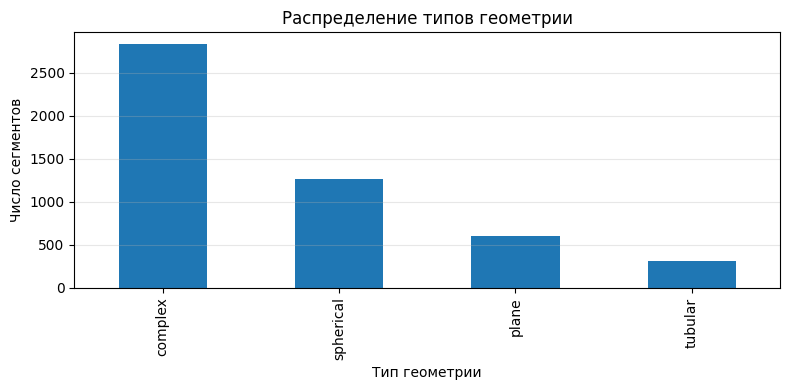

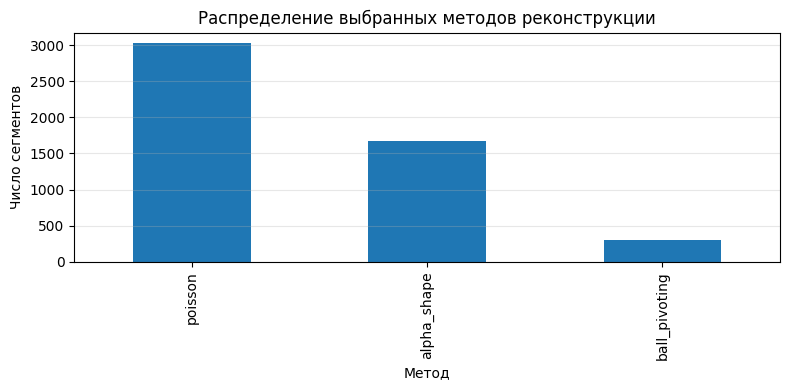

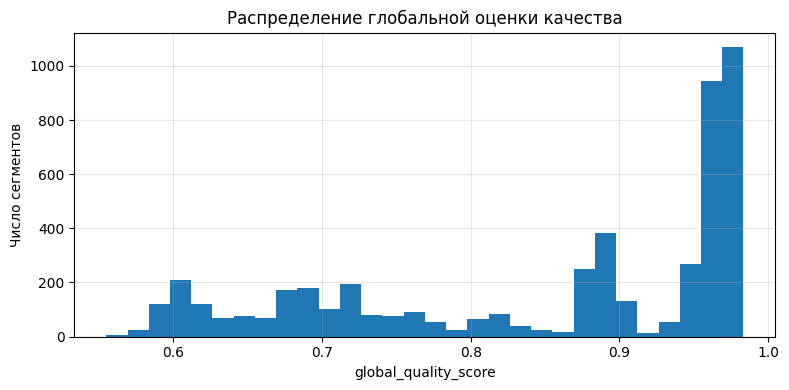

In [20]:
if len(all_metrics_df) > 0:
    plt.figure(figsize=(8, 4))
    all_metrics_df["geometry_type"].value_counts().plot(kind="bar")
    plt.title("Распределение типов геометрии")
    plt.xlabel("Тип геометрии")
    plt.ylabel("Число сегментов")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "geometry_type_distribution.png", dpi=200)
    plt.show()

    plt.figure(figsize=(8, 4))
    all_metrics_df["reconstruction_method"].value_counts().plot(kind="bar")
    plt.title("Распределение выбранных методов реконструкции")
    plt.xlabel("Метод")
    plt.ylabel("Число сегментов")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "reconstruction_method_distribution.png", dpi=200)
    plt.show()

    if "global_quality_score" in all_metrics_df.columns:
        plt.figure(figsize=(8, 4))
        all_metrics_df["global_quality_score"].dropna().hist(bins=30)
        plt.title("Распределение глобальной оценки качества")
        plt.xlabel("global_quality_score")
        plt.ylabel("Число сегментов")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "global_quality_score_hist.png", dpi=200)
        plt.show()

## 14. Сравнение методов реконструкции на подвыборке

In [21]:
def compare_methods_on_subset(files: List[Path], n_files: int = 5, methods: List[str] = ["alpha_shape", "ball_pivoting", "poisson"]) -> pd.DataFrame:
    """Запускает все методы на сегментах первых n_files и сравнивает метрики."""
    if not O3D_AVAILABLE:
        raise ImportError("Для сравнения методов требуется Open3D")

    rows = []
    for path in tqdm(files[:n_files], desc="Сравнение методов"):
        raw_df = read_ascii_ply(path)
        pre_df, _ = preprocess_cloud(raw_df, remove_outliers=True, normalize=True, voxel_size=VOXEL_SIZE)
        segments = split_into_segments(pre_df, min_points=MIN_SEGMENT_POINTS)

        for segment in segments:
            points = segment["points"]
            feats = analyze_segment(points)
            geometry_type = classify_geometry(feats)

            for method in methods:
                row = {
                    "file": path.name,
                    "label": segment["label"],
                    "geometry_type": geometry_type,
                    "method": method,
                    "status": "ok",
                    "error": None,
                }
                try:
                    mesh = reconstruct_segment(points, method)
                    row.update(evaluate_reconstruction(points, mesh))
                except Exception as exc:
                    row["status"] = "error"
                    row["error"] = repr(exc)
                rows.append(row)
    return pd.DataFrame(rows)

method_comparison_df = compare_methods_on_subset(ply_files, n_files=min(5, len(ply_files))) if O3D_AVAILABLE else pd.DataFrame()
method_comparison_path = METRICS_DIR / "method_comparison_subset.csv"
method_comparison_df.to_csv(method_comparison_path, index=False)

display(method_comparison_df.head())

if len(method_comparison_df) > 0:
    display(method_comparison_df.groupby("method")[[
        "pc_to_mesh_rmse", "chamfer_mean", "bad_triangle_ratio", "global_quality_score"
    ]].mean(numeric_only=True).sort_values("global_quality_score", ascending=False))

Сравнение методов:   0%|          | 0/5 [00:00<?, ?it/s]

,file,label,geometry_type,method,status,error,pc_to_mesh_mean,pc_to_mesh_rmse,pc_to_mesh_p95,mesh_to_pc_mean,...,smoothness_score,n_vertices,n_triangles,bad_triangle_ratio,mean_aspect_ratio,artifact_score,rmse_normalized,accuracy_score,connectivity_score,global_quality_score
0,valve_0001_lidar_classes.ply,0,spherical,alpha_shape,ok,None,0.016933,0.022452,0.046979,0.006174,...,0.420445,573,815,0.012270,2.293218,0.987730,0.041858,0.959823,0.009174,0.594293
1,valve_0001_lidar_classes.ply,0,spherical,ball_pivoting,ok,None,0.007161,0.008160,0.014307,0.005914,...,0.937718,1169,2238,0.003575,1.812686,0.996425,0.015213,0.985015,1.000000,0.979789
2,valve_0001_lidar_classes.ply,0,spherical,poisson,ok,None,0.007542,0.008645,0.014965,0.007551,...,0.957090,2270,4319,0.037509,3.708481,0.962491,0.016117,0.984138,1.000000,0.975930
3,valve_0001_lidar_classes.ply,1,spherical,alpha_shape,ok,None,0.016461,0.021970,0.046827,0.007539,...,0.418280,580,842,0.003563,2.100068,0.996437,0.042860,0.958901,0.009174,0.595698
4,valve_0001_lidar_classes.ply,1,spherical,ball_pivoting,ok,None,0.007601,0.008546,0.014288,0.006788,...,0.923051,1078,2069,0.003867,1.872390,0.996133,0.016673,0.983600,1.000000,0.975696


,pc_to_mesh_rmse,chamfer_mean,bad_triangle_ratio,global_quality_score
method,,,,
ball_pivoting,0.007026,0.013442,0.004092,0.912317
poisson,0.007739,0.018477,0.055022,0.864647
alpha_shape,0.012907,0.017027,0.004383,0.714766


## 15. Визуализация собранной модели

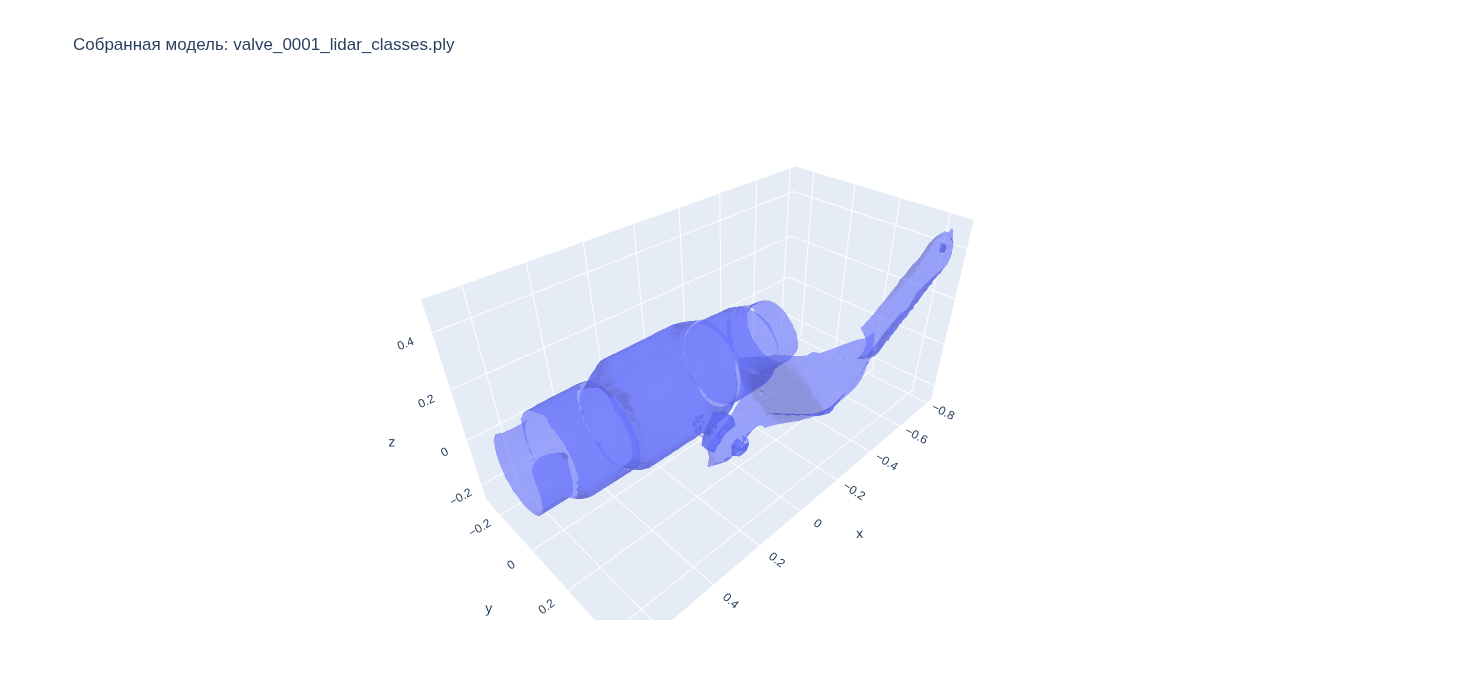

In [22]:
def plot_mesh_plotly(mesh: "o3d.geometry.TriangleMesh", title: str = "Reconstructed mesh"):
    if not PLOTLY_AVAILABLE:
        print("Plotly недоступен")
        return
    vertices = np.asarray(mesh.vertices)
    triangles = np.asarray(mesh.triangles)
    if len(vertices) == 0 or len(triangles) == 0:
        print("Пустая mesh-модель")
        return
    fig = go.Figure(data=[go.Mesh3d(
        x=vertices[:, 0], y=vertices[:, 1], z=vertices[:, 2],
        i=triangles[:, 0], j=triangles[:, 1], k=triangles[:, 2],
        opacity=0.6,
    )])
    fig.update_layout(title=title, height=700)
    fig.show()

if O3D_AVAILABLE and one_mesh is not None:
    plot_mesh_plotly(one_mesh, title=f"Собранная модель: {ply_files[0].name}")
else:
    print("Mesh не построена: проверьте наличие Open3D и выполнение ячейки process_one_file.")

## 16. Автоматическая генерация краткого отчета

In [23]:
def generate_lab_report(
    summary_df: pd.DataFrame,
    all_metrics_df: pd.DataFrame,
    method_comparison_df: pd.DataFrame,
    output_path: Path = OUTPUT_DIR / "lab2_report.md",
) -> str:
    n_files = len(summary_df)
    n_points_mean = summary_df["n_points"].mean() if "n_points" in summary_df else np.nan
    n_segments_median = summary_df["n_segments"].median() if "n_segments" in summary_df else np.nan

    lines = []
    lines.append("# Отчет по лабораторной работе 2")
    lines.append("")
    lines.append("## Цель")
    lines.append("Разработан pipeline адаптивной реконструкции поверхностей по размеченным облакам точек ТЛО.")
    lines.append("")
    lines.append("## Исходные данные")
    lines.append(f"Обработано файлов: **{n_files}**.")
    lines.append(f"Среднее число точек на объект: **{n_points_mean:.1f}**.")
    lines.append(f"Медианное число сегментов на объект: **{n_segments_median:.1f}**.")
    lines.append("")
    lines.append("## Реализованный pipeline")
    lines.append("1. Загрузка ASCII `.ply` файлов.")
    lines.append("2. Проверка корректности данных, удаление некорректных точек и выбросов.")
    lines.append("3. Нормализация координат и опциональный downsampling.")
    lines.append("4. Формирование сегментов по `label`.")
    lines.append("5. Расчет PCA-признаков, плотности, связности и согласованности нормалей.")
    lines.append("6. Классификация сегментов на плоские, трубчатые, сферические и сложные.")
    lines.append("7. Автоматический выбор метода реконструкции: Alpha Shapes, Ball Pivoting или Poisson.")
    lines.append("8. Сборка сегментных mesh-моделей в единую модель объекта.")
    lines.append("9. Расчет метрик качества реконструкции.")
    lines.append("")

    if len(all_metrics_df) > 0:
        ok_df = all_metrics_df[all_metrics_df["status"] == "ok"] if "status" in all_metrics_df else all_metrics_df
        lines.append("## Основные результаты")
        lines.append(f"Количество обработанных сегментов: **{len(all_metrics_df)}**.")
        lines.append(f"Успешно реконструированных сегментов: **{len(ok_df)}**.")
        for col in ["pc_to_mesh_rmse", "chamfer_mean", "bad_triangle_ratio", "global_quality_score"]:
            if col in ok_df:
                lines.append(f"Среднее `{col}`: **{ok_df[col].mean():.6f}**.")
        lines.append("")

        if "geometry_type" in all_metrics_df:
            lines.append("## Распределение типов геометрии")
            geom_counts = all_metrics_df["geometry_type"].value_counts()
            for k, v in geom_counts.items():
                lines.append(f"- {k}: {v}")
            lines.append("")

        if "reconstruction_method" in all_metrics_df:
            lines.append("## Распределение выбранных методов")
            method_counts = all_metrics_df["reconstruction_method"].value_counts()
            for k, v in method_counts.items():
                lines.append(f"- {k}: {v}")
            lines.append("")

    if len(method_comparison_df) > 0:
        lines.append("## Сравнение методов на подвыборке")
        cmp = method_comparison_df.groupby("method")[["pc_to_mesh_rmse", "chamfer_mean", "global_quality_score"]].mean(numeric_only=True)
        lines.append(cmp.to_markdown())
        lines.append("")

    lines.append("## Вывод")
    lines.append(
        "Реализованный pipeline позволяет автоматически обрабатывать облака точек, выделять сегменты по готовой разметке, "
        "оценивать геометрические характеристики каждого сегмента и выбирать метод реконструкции на основе этих признаков. "
        "Качество реконструкции оценивается по отклонению от исходного облака, гладкости, связности, артефактам и интегральной оценке."
    )

    report = "\n".join(lines)
    output_path.write_text(report, encoding="utf-8")
    return report

report_text = generate_lab_report(summary_df, all_metrics_df, method_comparison_df)
print(report_text[:4000])
print("\nОтчет сохранен:", OUTPUT_DIR / "lab2_report.md")

# Отчет по лабораторной работе 2

## Цель
Разработан pipeline адаптивной реконструкции поверхностей по размеченным облакам точек ТЛО.

## Исходные данные
Обработано файлов: **500**.
Среднее число точек на объект: **7787.5**.
Медианное число сегментов на объект: **10.0**.

## Реализованный pipeline
1. Загрузка ASCII `.ply` файлов.
2. Проверка корректности данных, удаление некорректных точек и выбросов.
3. Нормализация координат и опциональный downsampling.
4. Формирование сегментов по `label`.
5. Расчет PCA-признаков, плотности, связности и согласованности нормалей.
6. Классификация сегментов на плоские, трубчатые, сферические и сложные.
7. Автоматический выбор метода реконструкции: Alpha Shapes, Ball Pivoting или Poisson.
8. Сборка сегментных mesh-моделей в единую модель объекта.
9. Расчет метрик качества реконструкции.

## Основные результаты
Количество обработанных сегментов: **4998**.
Успешно реконструированных сегментов: **4998**.
Среднее `pc_to_mesh_rmse`: **0.008403**.
Среднее `c